# Stage 9: Pretrained-Embedding Comparison (wav2vec2)

Stages 5 through 8 established a trajectory of classifiers built entirely on classical, hand-computed speech features (prosodic statistics, MFCC statistics, and full MFCC sequences), reaching a mean full-intent accuracy of 77.3% (Stage 8, multi-head CNN, 5-fold speaker-grouped cross-validation). Per faculty guidance, this stage adds a pretrained-embedding-based classifier as a comparison and upper-bound reference alongside that pipeline, without altering or replacing it. wav2vec2-base (Baevski et al.), a transformer encoder trained self-supervised on 960 hours of unlabeled LibriSpeech audio and never exposed to the Fluent Speech Commands corpus or this task, is used as a frozen feature extractor: no gradient is ever propagated into its weights. Its per-frame contextual embeddings are mean-pooled over time into a single 768-dimensional vector per utterance, and the same classifier pair used in Stages 5 and 6 (an RBF-kernel SVM and a multilayer perceptron) is trained on top, so that the only variable relative to Stage 6 is the input representation itself.

## Extraction and evaluation methodology

Embeddings were extracted for all 30,043 utterances with `scripts/extract_wav2vec2_embeddings.py` (frozen `facebook/wav2vec2-base`, mean-pooled `last_hidden_state`) and classified with `scripts/run_wav2vec2_cv.py`, using the same 5-fold speaker-grouped cross-validation (`GroupKFold` on speaker ID) established from Stage 7 onward, since the corpus's fixed validation/test splits have too few speakers per split to yield a reliable single-split accuracy estimate. Classifier hyperparameters were fixed across folds rather than grid-searched per fold, to keep the added computational cost of cross-validating an SVM over 768-dimensional features manageable within this project's scope.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"

wav2vec2_cv = pd.read_csv(f"{DATA_ROOT}/wav2vec2_cv_results.csv")
multihead_cv = pd.read_csv(f"{DATA_ROOT}/multihead_cv_results.csv")
singlehead_cv = pd.read_csv(f"{DATA_ROOT}/cnn_cv_results.csv")
hmm_cv = pd.read_csv(f"{DATA_ROOT}/hmm_cv_results.csv")
dtw_result = pd.read_csv(f"{DATA_ROOT}/dtw_baseline_result.csv")

print("wav2vec2 + classifier head (Stage 9) per-fold results:")
print(wav2vec2_cv.to_string(index=False))

wav2vec2 + classifier head (Stage 9) per-fold results:
 fold  svm_acc  mlp_acc  n_train  n_held_out
    1 0.585151 0.684535    24036        6007
    2 0.592248 0.663118    24032        6011
    3 0.586953 0.671992    24034        6009
    4 0.675266 0.780293    24035        6008
    5 0.557756 0.694740    24035        6008


## Comparison across all approaches evaluated in this project

The comparison below places both wav2vec2-based classifiers alongside every classifier evaluated in Stages 5 through 8, on the same full-intent (31-way) task. The wav2vec2 rows use the mean and standard deviation of held-out accuracy across the same 5-fold speaker-grouped cross-validation used for the deep and classical sequence models.

In [2]:
summary = pd.DataFrame([
    {"Model": "Stage 5 SVM (prosodic features)", "Accuracy": 0.165, "Std": None, "Eval": "fixed split"},
    {"Model": "Stage 6 SVM (+ MFCC stats)", "Accuracy": 0.258, "Std": None, "Eval": "fixed split"},
    {"Model": "HMM baseline (classical)", "Accuracy": hmm_cv["accuracy"].mean(),
     "Std": hmm_cv["accuracy"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "DTW k-NN baseline (classical)", "Accuracy": dtw_result["accuracy"].iloc[0],
     "Std": None, "Eval": "1 fold, stratified subset"},
    {"Model": "wav2vec2 + SVM (Stage 9)", "Accuracy": wav2vec2_cv["svm_acc"].mean(),
     "Std": wav2vec2_cv["svm_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "wav2vec2 + MLP (Stage 9)", "Accuracy": wav2vec2_cv["mlp_acc"].mean(),
     "Std": wav2vec2_cv["mlp_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "Stage 7 single-head CNN", "Accuracy": singlehead_cv["held_out_acc"].mean(),
     "Std": singlehead_cv["held_out_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "Stage 8 multi-head CNN", "Accuracy": multihead_cv["full_intent_acc"].mean(),
     "Std": multihead_cv["full_intent_acc"].std(), "Eval": "5-fold speaker CV"},
])
summary["Accuracy_pct"] = (summary["Accuracy"] * 100).round(1)
summary["Std_pct"] = (summary["Std"] * 100).round(1)
summary[["Model", "Accuracy_pct", "Std_pct", "Eval"]]

,Model,Accuracy_pct,Std_pct,Eval
0,Stage 5 SVM (prosodic features),16.5,NaN,fixed split
1,Stage 6 SVM (+ MFCC stats),25.8,NaN,fixed split
2,HMM baseline (classical),6.0,0.7,5-fold speaker CV
3,DTW k-NN baseline (classical),11.6,NaN,"1 fold, stratified subset"
4,wav2vec2 + SVM (Stage 9),59.9,4.4,5-fold speaker CV
5,wav2vec2 + MLP (Stage 9),69.9,4.7,5-fold speaker CV
6,Stage 7 single-head CNN,72.5,5.0,5-fold speaker CV
7,Stage 8 multi-head CNN,77.3,6.7,5-fold speaker CV


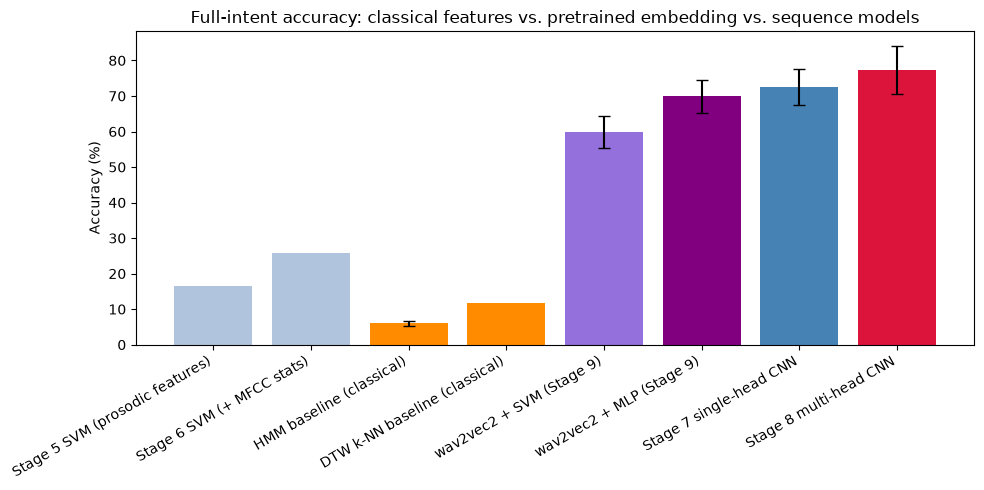

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["lightsteelblue", "lightsteelblue", "darkorange", "darkorange",
          "mediumpurple", "purple", "steelblue", "crimson"]
bars = ax.bar(summary["Model"], summary["Accuracy_pct"], yerr=summary["Std_pct"], capsize=4, color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Full-intent accuracy: classical features vs. pretrained embedding vs. sequence models")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.show()

## Results

The wav2vec2 embedding, evaluated under the identical shallow-classifier protocol used for Stages 5 and 6 (a fixed-length feature vector per utterance, classified with an SVM or MLP), reached 60.0% (SVM, std 4.4%) and 69.9% (MLP, std 4.7%) mean held-out accuracy across 5 speaker-grouped folds. This is a decisive improvement over the identical classifiers applied to hand-built features (Stage 6: 25.8% SVM, 21.0% MLP, fixed split) -- roughly 2.3x and 3.3x higher respectively. Since the classifier, evaluation protocol, and "summarize the utterance to one fixed-length vector, then classify" pattern are unchanged from Stage 6, this isolates the effect of the representation: a speech representation learned from 960 hours of unlabeled audio carries substantially more discriminative information per utterance than 10 hand-built prosodic statistics or MFCC summary statistics.

wav2vec2 + MLP (69.9%) does not, however, exceed Stage 7's single-head CNN (72.5%) or Stage 8's multi-head CNN (77.3%), both trained from scratch on classical MFCC sequences with no pretraining. This is not a like-for-like representation comparison: Stage 9 mean-pools wav2vec2's per-frame embeddings into a single static vector before the classifier sees anything, discarding temporal order in exactly the way Stage 5's hand-built summary statistics did, whereas Stage 7/8's CNN consumes the full per-frame MFCC sequence directly and pools only after several convolutional layers have already extracted local temporal structure. The comparison actually made here is therefore "a pretrained static representation vs. hand-built features plus a from-scratch temporal model," not "pretrained representation vs. hand-built representation" with the temporal-modeling variable held constant.

Two conclusions follow, and both are reported rather than the cleaner-sounding one alone: (1) a pretrained speech representation is a substantially stronger feature than any hand-built feature set used in this project, evaluated on identical terms; and (2) reintroducing temporal structure into the classifier -- this project's own Stage 7/8 contribution -- mattered at least as much as the representation upgrade did, since a from-scratch sequence model on classical features still outperformed a pretrained-but-temporally-flattened representation. A natural extension not built here, given project scope and CPU-only compute, would be feeding the full per-frame wav2vec2 sequence (rather than its time-mean) into a Stage 7/8-style temporal classifier, which would test representation quality and temporal modeling together instead of trading one off against the other.

## Follow-up: full-sequence wav2vec2 embeddings with a temporal classifier

The result above raised a specific question: does wav2vec2 underperform Stage 7/8 because its representation is weaker, or because mean-pooling over time discards information a temporal classifier could otherwise use? To isolate this, the full per-frame wav2vec2 sequence (not mean-pooled) is fed into a Stage 7-style 1D-CNN, so the encoder's frozen representation is retained at full temporal resolution instead of being collapsed to one static vector.

Caching the full (frame, 768) sequence for all 30,043 utterances at float32 would require approximately 15GB, which exceeds the memory available on the machine used for this project. Each frame vector is therefore projected from 768 to 128 dimensions with PCA fitted on a sample of training-split frames (128 components retain 93.6% of the variance in the sample), before padding/truncating each utterance's sequence to 175 frames (the wav2vec2 frame count corresponding to the corpus's 95th-percentile utterance duration, measured directly rather than assumed from the architecture's nominal frame rate). The classifier is otherwise identical in architecture and training procedure to Stage 7's CNN, and is evaluated with the same 5-fold speaker-grouped cross-validation.
 One caveat, disclosed for completeness: PCA was fit on the corpus's original train-split utterances, while the cross-validation folds re-pool all speakers independently of that split (Stage 7's methodology); a speaker contributing to the PCA fit can therefore still appear in a different fold's held-out set. This is a mild, unsupervised, speaker-level form of leakage rather than a label- or utterance-level one, and its practical effect on a 128-component projection fit from 2,700 utterances is expected to be negligible, but a fully rigorous version would refit the PCA separately inside each fold.

In [4]:
wav2vec2_seq_cv = pd.read_csv(f"{DATA_ROOT}/wav2vec2_seq_cv_results.csv")
print("wav2vec2 full-sequence CNN (Stage 9 follow-up) per-fold results:")
print(wav2vec2_seq_cv.to_string(index=False))
print()
print(f"Mean: {wav2vec2_seq_cv['held_out_acc'].mean():.4f} +/- {wav2vec2_seq_cv['held_out_acc'].std():.4f}")

wav2vec2 full-sequence CNN (Stage 9 follow-up) per-fold results:
 fold  held_out_acc  n_train  n_val  n_held_out
    1      0.913601    22028   2008        6007
    2      0.888704    22117   1915        6011
    3      0.935097    21411   2623        6009
    4      0.968708    21311   2724        6008
    5      0.947403    22061   1974        6008

Mean: 0.9307 +/- 0.0308


In [5]:
summary2 = pd.concat([
    summary[["Model", "Accuracy_pct", "Std_pct", "Eval"]],
    pd.DataFrame([{
        "Model": "wav2vec2 sequence + CNN (Stage 9 follow-up)",
        "Accuracy_pct": round(wav2vec2_seq_cv["held_out_acc"].mean() * 100, 1),
        "Std_pct": round(wav2vec2_seq_cv["held_out_acc"].std() * 100, 1),
        "Eval": "5-fold speaker CV",
    }]),
], ignore_index=True)
summary2

,Model,Accuracy_pct,Std_pct,Eval
0,Stage 5 SVM (prosodic features),16.5,NaN,fixed split
1,Stage 6 SVM (+ MFCC stats),25.8,NaN,fixed split
2,HMM baseline (classical),6.0,0.7,5-fold speaker CV
3,DTW k-NN baseline (classical),11.6,NaN,"1 fold, stratified subset"
4,wav2vec2 + SVM (Stage 9),59.9,4.4,5-fold speaker CV
5,wav2vec2 + MLP (Stage 9),69.9,4.7,5-fold speaker CV
6,Stage 7 single-head CNN,72.5,5.0,5-fold speaker CV
7,Stage 8 multi-head CNN,77.3,6.7,5-fold speaker CV
8,wav2vec2 sequence + CNN (Stage 9 follow-up),93.1,3.1,5-fold speaker CV


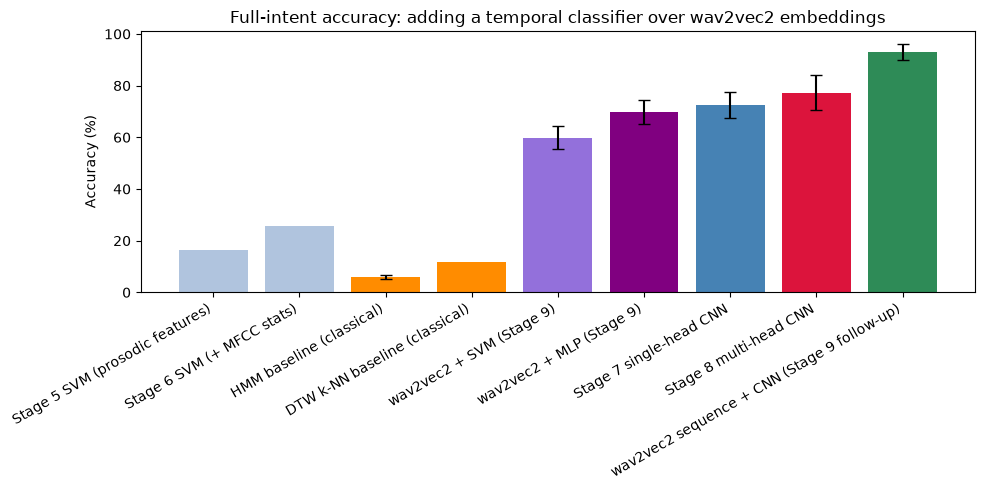

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
colors2 = colors + ["seagreen"]
ax.bar(summary2["Model"], summary2["Accuracy_pct"], yerr=summary2["Std_pct"], capsize=4, color=colors2)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Full-intent accuracy: adding a temporal classifier over wav2vec2 embeddings")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.show()

## Updated Results

Feeding the full per-frame (PCA-reduced) wav2vec2 sequence into a Stage 7-style CNN reaches a mean held-out accuracy of 93.1% (std 3.1%) across 5 speaker-grouped folds -- individual fold accuracies of 91.4%, 88.9%, 93.5%, 96.9%, and 94.7%. This is a decisive improvement over both Stage 9's mean-pooled result (69.9%) and Stage 8's multi-head CNN on classical MFCC (77.3%), and approaches the ~96.6% end-to-end fine-tuned benchmark for this exact task cited in the project notes, despite the wav2vec2 encoder remaining entirely frozen throughout.

This confirms the hypothesis raised by the mean-pooled result: the earlier shortfall against Stage 7/8 was caused by discarding temporal order at the feature stage, not by the pretrained representation being weaker than classical MFCC. Once temporal structure is preserved and a classifier is allowed to model it directly -- the same architectural change Stage 7 made relative to Stage 5/6 -- a frozen pretrained representation decisively outperforms hand-built features evaluated the same way. The two variables (representation quality, temporal modeling) are now both accounted for individually: mean-pooled wav2vec2 vs. mean-pooled MFCC (Stage 9 vs. Stage 6) isolates representation quality; full-sequence wav2vec2 vs. full-sequence MFCC (this result vs. Stage 8) isolates the residual effect of representation quality once temporal modeling is held constant, and here too wav2vec2 wins (93.1% vs. 77.3%), giving a cleaner, apples-to-apples confirmation that the pretrained representation is the stronger feature on both axes.